In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
print("Rows, Columns:", df.shape)

Rows, Columns: (1470, 35)


In [4]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [6]:
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [7]:
num_cols = df.select_dtypes(include="number").columns

cat_cols = df.select_dtypes(include="object").columns

print("Numeric Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numeric Columns: 26
Categorical Columns: 9


In [8]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [9]:
df.isnull().sum().sum()

0

In [10]:
drop_cols = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

df.drop(columns=drop_cols, inplace=True)

df.shape

(1470, 31)

In [11]:
df.shape

(1470, 31)

In [12]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [13]:
df["Attrition"].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [14]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1470, 30)
y Shape: (1470,)


In [15]:
cat_cols = X.select_dtypes(include="object").columns

print(cat_cols)
print("Total Categorical Columns:", len(cat_cols))

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')
Total Categorical Columns: 7


In [17]:
X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


In [18]:
print(X.shape)

(1470, 44)


In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(1470, 44)


In [22]:
dept_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

dept_attrition

Attrition,0,1
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

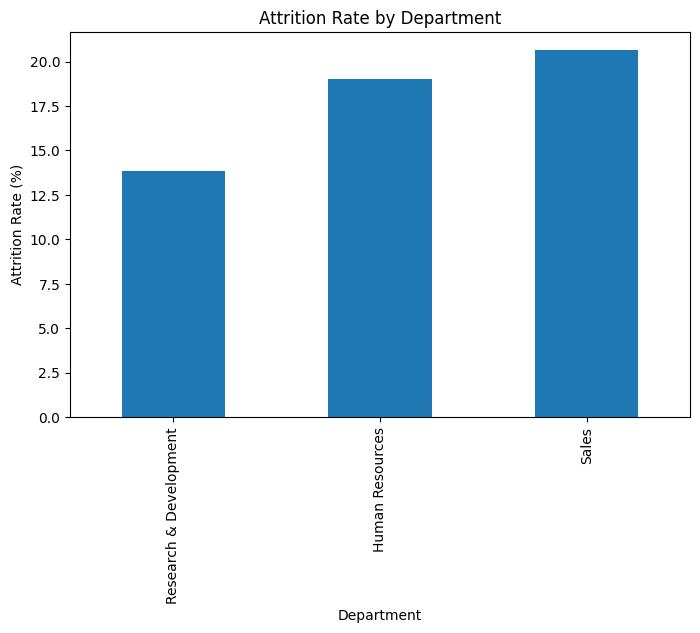

In [25]:
dept_attrition[1].sort_values().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")
plt.show()

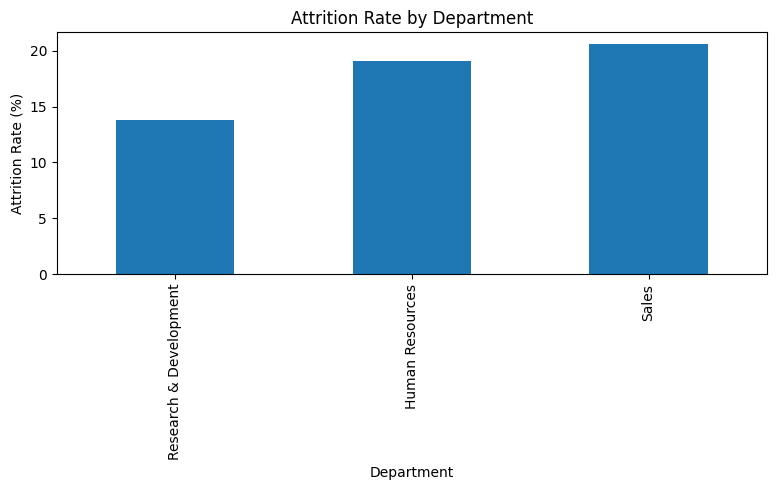

In [31]:
plt.figure(figsize=(8,5))

dept_attrition[1].sort_values().plot(
    kind="bar"
)

plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")

plt.tight_layout()

plt.savefig(
    "charts/chart1_attrition_by_department.png",
    bbox_inches="tight"
)

plt.show()

In [26]:
job_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

job_attrition

Attrition,0,1
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


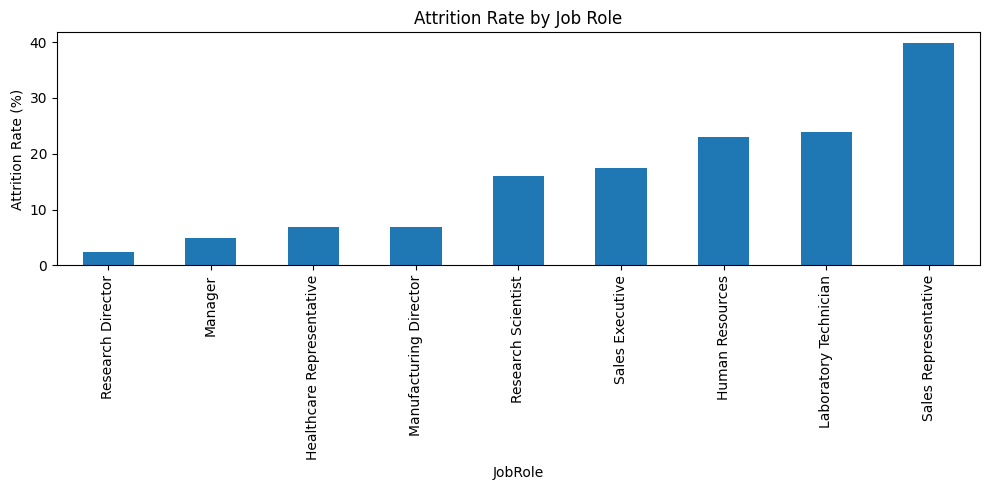

In [27]:
plt.figure(figsize=(10,5))

job_attrition[1].sort_values().plot(
    kind="bar"
)

plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

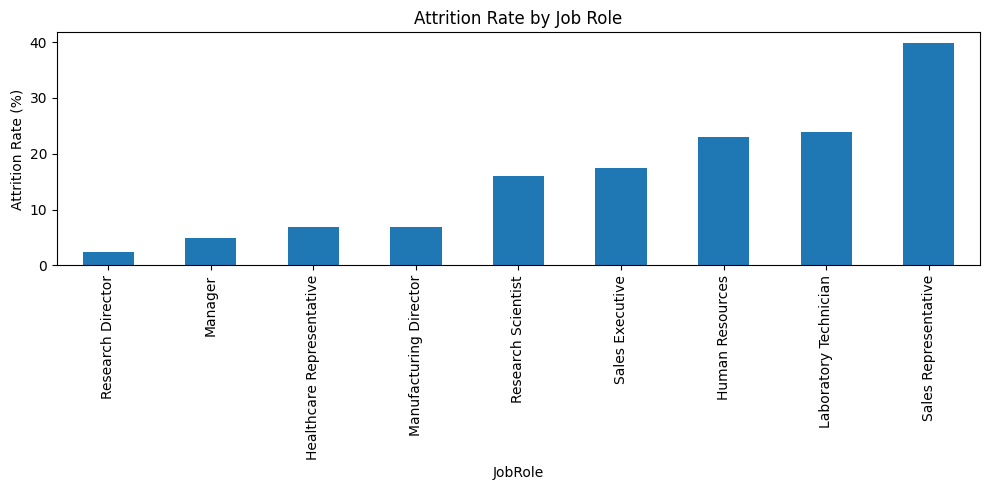

In [32]:
plt.figure(figsize=(10,5))

job_attrition[1].sort_values().plot(kind="bar")

plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("charts/chart2_attrition_by_jobrole.png")

plt.show()

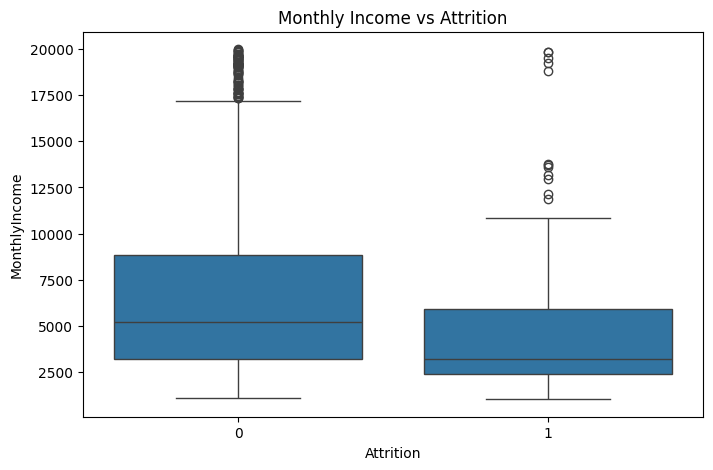

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income vs Attrition")

plt.savefig(
    "charts/chart3_income_vs_attrition.png",
    bbox_inches="tight"
)

plt.show()

In [34]:
df.groupby("Attrition")["MonthlyIncome"].mean()

Attrition
0    6832.739659
1    4787.092827
Name: MonthlyIncome, dtype: float64

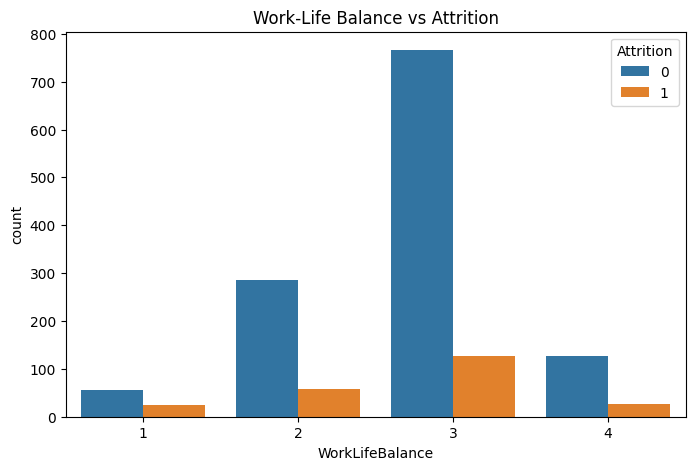

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="WorkLifeBalance",
    hue="Attrition",
    data=df
)

plt.title("Work-Life Balance vs Attrition")

plt.savefig(
    "charts/chart4_worklife_balance.png",
    bbox_inches="tight"
)

plt.show()

In [36]:
pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,0,1
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


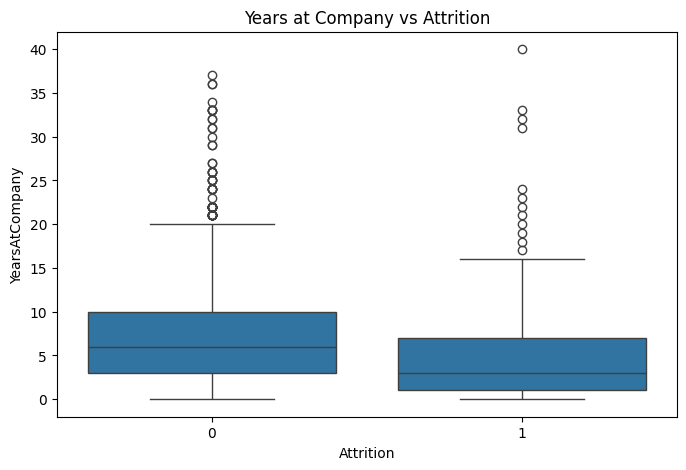

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="YearsAtCompany",
    data=df
)

plt.title("Years at Company vs Attrition")

plt.savefig(
    "charts/chart5_years_at_company.png",
    bbox_inches="tight"
)

plt.show()

In [38]:
df.groupby("Attrition")["YearsAtCompany"].mean()

Attrition
0    7.369019
1    5.130802
Name: YearsAtCompany, dtype: float64

# Business Insights from EDA

1. Sales department has the highest attrition rate (~21%), indicating that retention efforts should be prioritized in this department.

2. Employees who left earned an average monthly income of 4,787, compared to 6,833 for employees who stayed.

3. Employees with Work-Life Balance rating 1 have an attrition rate of 31.25%, significantly higher than other groups.

4. Employees who left had an average tenure of 5.13 years compared to 7.37 years for employees who stayed.

5. Overtime, frequent business travel, and sales-related roles are among the strongest drivers of attrition.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 44)
(294, 44)


In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [42]:
y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:,1]

In [43]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

print(classification_report(y_test, y_pred_lr))

print("ROC AUC Score:",
      roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

ROC AUC Score: 0.798604530967353


In [44]:
from sklearn.ensemble import RandomForestClassifier

In [45]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [46]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

In [47]:
print(classification_report(y_test, y_pred_rf))

print(
    "ROC AUC Score:",
    roc_auc_score(y_test, y_prob_rf)
)

              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

ROC AUC Score: 0.7716426910155914


In [48]:
from sklearn.ensemble import GradientBoostingClassifier

In [49]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [50]:
y_pred_gb = gb.predict(X_test)

y_prob_gb = gb.predict_proba(X_test)[:,1]

In [51]:
print(classification_report(y_test, y_pred_gb))

print(
    "ROC AUC Score:",
    roc_auc_score(y_test, y_prob_gb)
)

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294

ROC AUC Score: 0.7941252476526832


In [52]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Recall": [
        0.62,
        0.09,
        0.21
    ],
    "F1 Score": [
        0.44,
        0.15,
        0.31
    ],
    "ROC AUC": [
        0.799,
        0.772,
        0.794
    ]
})

comparison

,Model,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.62,0.44,0.799
1,Random Forest,0.09,0.15,0.772
2,Gradient Boosting,0.21,0.31,0.794


In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

cm

array([[191,  56],
       [ 18,  29]], dtype=int64)

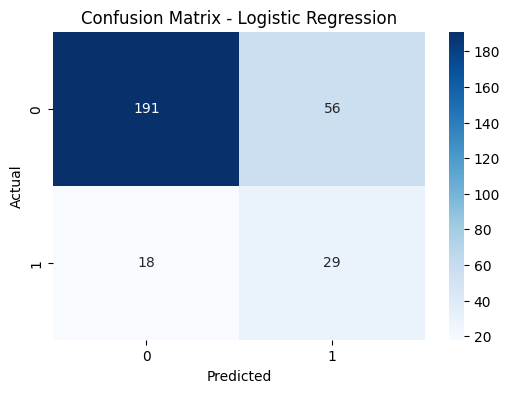

In [54]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "charts/chart6_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [55]:
cm

array([[191,  56],
       [ 18,  29]], dtype=int64)

In [56]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(lr.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.797874
43,OverTime_Yes,0.766412
23,BusinessTravel_Travel_Frequently,0.719335
7,JobLevel,0.659189
16,TotalWorkingYears,0.656931
40,JobRole_Sales Representative,0.552515
24,BusinessTravel_Travel_Rarely,0.511649
27,EducationField_Life Sciences,0.506505
21,YearsSinceLastPromotion,0.500389
26,Department_Sales,0.481690


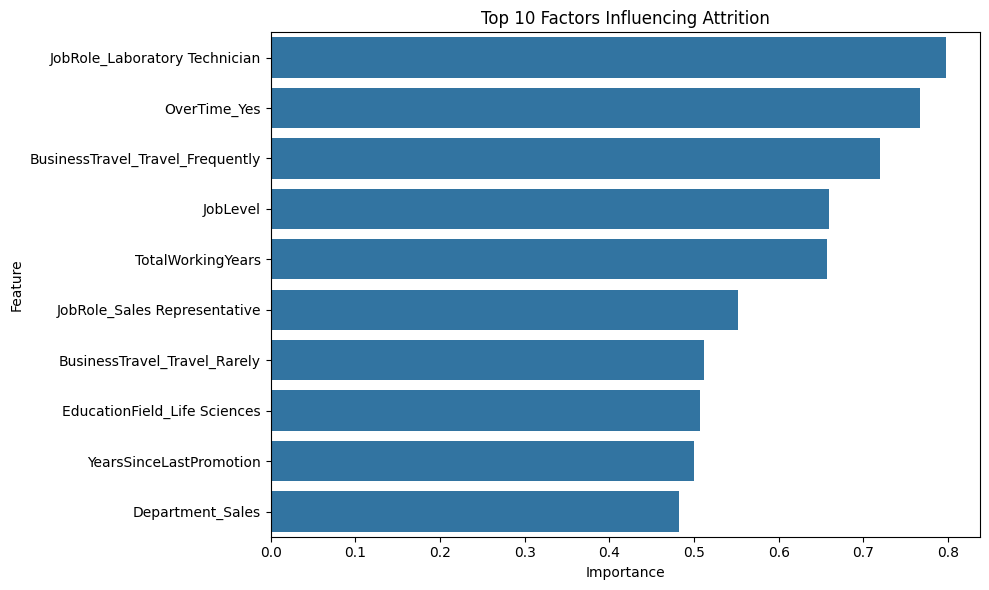

In [57]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top10
)

plt.title("Top 10 Factors Influencing Attrition")

plt.tight_layout()

plt.savefig(
    "charts/chart7_top10_features.png",
    bbox_inches="tight"
)

plt.show()

# HR Insights & Business Recommendations

### Which 3 factors most strongly predict attrition?

Overtime, frequent business travel, and specific job roles such as Laboratory Technician and Sales Representative are the strongest predictors.

### Which department or job role should HR prioritize?

The Sales department should be prioritized because it has the highest attrition rate among all departments.

### Does salary alone explain attrition?

No. Salary contributes to attrition, but overtime, work-life balance, promotion opportunities, and job role are also important factors.

### Recommendation 1

Reduce excessive overtime and improve workload management to improve employee satisfaction and retention.

### Recommendation 2

Create targeted retention programs for Sales employees, Laboratory Technicians, and employees who frequently travel for business.

### Limitation

The model is trained on historical HR data and cannot capture personal factors such as family circumstances, career aspirations, external job opportunities, or economic conditions.

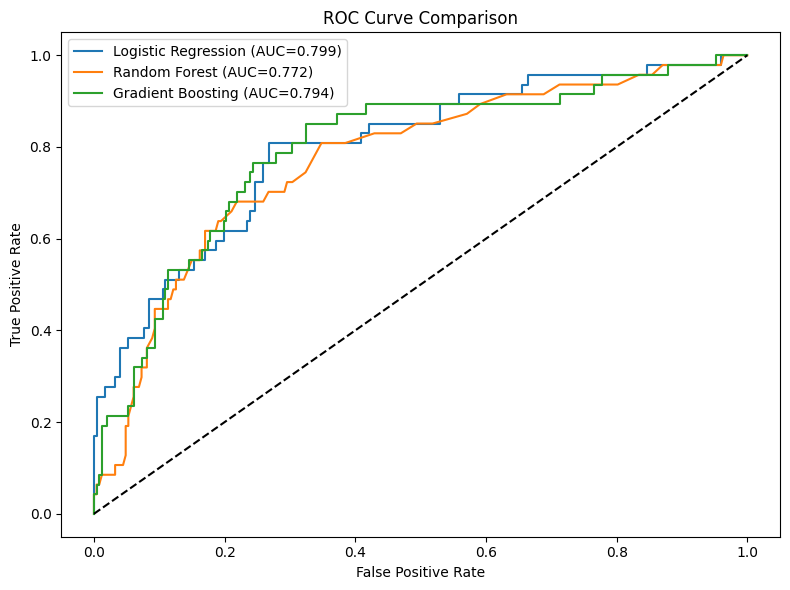

In [59]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.plot(fpr_lr, tpr_lr,
         label="Logistic Regression (AUC=0.799)")

plt.plot(fpr_rf, tpr_rf,
         label="Random Forest (AUC=0.772)")

plt.plot(fpr_gb, tpr_gb,
         label="Gradient Boosting (AUC=0.794)")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/chart8_roc_curve.png",
    bbox_inches="tight"
)

plt.show()

## ROC Curve Analysis

The ROC Curve comparison shows that Logistic Regression achieved the highest ROC-AUC score (0.799), followed closely by Gradient Boosting (0.794). Random Forest achieved the lowest ROC-AUC score (0.772). This further supports the selection of Logistic Regression as the best model for employee attrition prediction.